# Build SpatialData - blocco 1

Questo notebook costruisce uno `SpatialData` per `blocco1` partendo da SpaceRanger HD, sostituendo la segmentazione dei nuclei con quella ARVIS, aggiungendo aree di interesse, H&E full resolution e segmentazione fibre. Alla fine salva:

- un oggetto per il blocco intero;
- tre oggetti ritagliati secondo `data/samples_he.json`, uno per sample;
- opzionalmente un unico `SpatialData` ottenuto riunendo i tre sample.

Le segmentazioni vengono tenute sia come `labels` raster sia, quando richiesto, come `shapes` poligonali. Il raster e' utile per conservare la maschera originale e visualizzare/salvare in modo compatto; i poligoni sono piu' comodi per join spaziali, annotazioni e aggregazioni successive.

In [1]:
# Controllo dipendenze. Eseguire questa cella prima di tutto.
import importlib.util

required = [
    "spatialdata",
    "spatialdata_io",
    "geopandas",
    "rasterio",
    "shapely",
    "dask_image",
    "numpy",
]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise ImportError(
        "Mancano queste dipendenze: " + ", ".join(missing) +
        "\nInstalla/attiva l'ambiente con spatialdata, spatialdata-io, geopandas, rasterio e dask-image."
    )
print("Dipendenze principali disponibili.")

Dipendenze principali disponibili.


In [2]:
from pathlib import Path
import json
import shutil

ROOT = Path("/Users/riccardo/Develop/cachectic_visiumHD")
BLOCK = "blocco1"

PATHS = {
    "spaceranger": ROOT / "data/SpaceRanger/blocco1/outs",
    "he_fullres": ROOT / "data/H&E/Project_BLOCCO_1_ch00.tif",
    "nuclei_labels": ROOT / "data/ARVIS/Project_BLOCCO_1_ch00.tif",
    "areas_of_interest": ROOT / "data/ARVIS/Project_Blocco_1_ch00_poli.geojson",
    "roi_metadata": ROOT / "data/ARVIS/Project_BLOCCO_1_ch00.geojson",
    "fibres_labels": ROOT / "data/CellPose/Project_BLOCCO_1_ch00.tif",
    "samples": ROOT / "data/samples_he.json",
    "out_dir": ROOT / "data/spatialdata",
}

# I poligoni da maschera possono essere pesanti. Tenerli True per analisi spaziali su nuclei/fibre.
MAKE_POLYGONS_FROM_MASKS = True
OVERWRITE = True

PATHS["out_dir"].mkdir(parents=True, exist_ok=True)
for key, path in PATHS.items():
    if key != "out_dir":
        assert path.exists(), f"File mancante per {key}: {path}"

with PATHS["samples"].open() as f:
    SAMPLES = json.load(f)[BLOCK]

SAMPLES

{'c26STAT3': {'min_coordinate': [0, 0],
  'max_coordinate': [16166, 8000],
  'sample_key': 'blocco1_c26STAT3'},
 'sham': {'min_coordinate': [0, 8000],
  'max_coordinate': [16166, 15000],
  'sample_key': 'blocco1_sham'},
 'c26foxO': {'min_coordinate': [0, 15000],
  'max_coordinate': [16166, 22718],
  'sample_key': 'blocco1_c26foxO'}}

In [3]:
import geopandas as gpd
import numpy as np
import rasterio
import rasterio.features
import shapely.geometry
from dask_image.imread import imread as dask_imread

from spatialdata import SpatialData, read_zarr
from spatialdata.models import Image2DModel, Labels2DModel, ShapesModel
from spatialdata.transformations import Identity, Translation, Sequence, get_transformation, set_transformation
from spatialdata_io import visium_hd


def write_sdata(sdata, path, overwrite=OVERWRITE):
    path = Path(path)
    if path.exists() and overwrite:
        shutil.rmtree(path)
    sdata.write(path)
    return path


def find_fullres_image_key(sdata, block=BLOCK):
    preferred = f"{block}_full_image"
    if preferred in sdata.images:
        return preferred
    fullres_like = [key for key in sdata.images if "full" in key.lower()]
    if fullres_like:
        return fullres_like[0]
    if len(sdata.images) == 1:
        return next(iter(sdata.images))
    raise KeyError(f"Non trovo l'immagine fullres. Immagini disponibili: {list(sdata.images)}")


def read_tiff_as_dask(path):
    arr = dask_imread(str(path))
    if arr.ndim >= 3 and arr.shape[0] == 1:
        arr = arr[0]
    return arr


def infer_image_dims(arr):
    if arr.ndim == 2:
        return ("y", "x")
    if arr.ndim == 3 and arr.shape[-1] in (1, 3, 4):
        return ("y", "x", "c")
    if arr.ndim == 3 and arr.shape[0] in (1, 3, 4):
        return ("c", "y", "x")
    raise ValueError(f"Shape immagine non gestita: {arr.shape}")


def read_label_raster(path):
    with rasterio.open(path) as src:
        return src.read(1)


def mask_to_polygons(mask, value_name="label_id"):
    geometries = []
    values = []
    mask = np.asarray(mask)
    for geometry, value in rasterio.features.shapes(
        mask.astype(np.int32),
        mask=mask > 0,
        connectivity=8,
    ):
        geometries.append(shapely.geometry.shape(geometry))
        values.append(int(value))
    gdf = gpd.GeoDataFrame({value_name: values, "geometry": geometries}, index=values)
    if len(values) != len(set(values)):
        gdf = gdf.dissolve(by=value_name)
        gdf[value_name] = gdf.index.astype(int)
    return gdf.set_crs(None, allow_override=True)


def add_geojson_shapes(sdata, path, key, coordinate_system, transformation):
    gdf = gpd.read_file(path).set_crs(None, allow_override=True)
    gdf.attrs = {}
    sdata.shapes[key] = ShapesModel.parse(
        gdf,
        transformations={coordinate_system: transformation},
    )
    return gdf


def add_label_mask(sdata, path, labels_key, shapes_key, coordinate_system, transformation, make_polygons=True):
    mask = read_label_raster(path)
    sdata.labels[labels_key] = Labels2DModel.parse(
        mask,
        dims=("y", "x"),
        transformations={coordinate_system: transformation},
    )
    if make_polygons:
        polygons = mask_to_polygons(mask)
        sdata.shapes[shapes_key] = ShapesModel.parse(
            polygons,
            transformations={coordinate_system: transformation},
        )
    return mask


def add_local_coordinate_system(sdata, source_coordinate_system, local_coordinate_system, min_coordinate):
    # Coordinate locali sample = coordinate blocco - min_coordinate.
    # Manteniamo anche il sistema globale del blocco per poter riunire facilmente gli oggetti.
    shift_to_local = Translation([-float(min_coordinate[0]), -float(min_coordinate[1])], axes=("x", "y"))
    for element in list(sdata.images.values()) + list(sdata.labels.values()) + list(sdata.shapes.values()):
        try:
            original = get_transformation(element, to_coordinate_system=source_coordinate_system)
            set_transformation(
                element,
                Sequence([original, shift_to_local]),
                to_coordinate_system=local_coordinate_system,
            )
        except Exception as exc:
            print(f"Skip trasformazione locale per {type(element)}: {exc}")
    return sdata

/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [4]:
# Caricamento SpaceRanger HD senza importare la segmentazione nuclei prodotta da SpaceRanger.
# La full-res H&E viene passata direttamente a spatialdata_io.visium_hd.
sdata_block = visium_hd(
    path=PATHS["spaceranger"],
    fullres_image_file=PATHS["he_fullres"],
    dataset_id=BLOCK,
    filtered_counts_file=False,
    bin_size=["002", "008", "016"],
    bins_as_squares=True,
    annotate_table_by_labels=False,
    load_all_images=False,
    var_names_make_unique=True,
    image_models_kwargs={"dims": ["c", "y", "x"]},
    load_segmentations_only=False,
    load_nucleus_segmentations=False,
)

image_key = find_fullres_image_key(sdata_block, BLOCK)
block_transform = get_transformation(sdata_block.images[image_key], to_coordinate_system=BLOCK)
print("Immagini:", list(sdata_block.images))
print("Labels:", list(sdata_block.labels))
print("Shapes:", list(sdata_block.shapes))
print("Tables:", list(sdata_block.tables))
print("Immagine fullres usata come riferimento:", image_key)

/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Found segmentation data. Incorporating cell_segmentations.


/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     `dims` is specified redundantly: found also inside `data`.                                                
INFO     `dims` is specified redundantly: found also inside `data`.                                                
INFO     `dims` is specified redundantly: found also inside `data`.                                                
Immagini: ['blocco1_full_image', 'blocco1_hires_image', 'blocco1_lowres_image']
Labels: []
Shapes: ['blocco1_square_002um', 'blocco1_square_008um', 'blocco1_square_016um', 'blocco1_cell_segmentations']
Tables: ['square_002um', 'square_008um', 'square_016um', 'cell_segmentations']
Immagine fullres usata come riferimento: blocco1_full_image


In [6]:
# Aggiunta ROI/aree di interesse e segmentazioni esterne.
# Aree di interesse indicate dall'utente: poligoni gia' pronti.
areas_of_interest = add_geojson_shapes(
    sdata_block,
    PATHS["areas_of_interest"],
    key="areas_of_interest_arvis",
    coordinate_system=BLOCK,
    transformation=block_transform,
)

# File ARVIS descrittivo opzionale, utile per ritrovare macro-regioni/classificazioni se serve.
roi_metadata = add_geojson_shapes(
    sdata_block,
    PATHS["roi_metadata"],
    key="roi_metadata_arvis",
    coordinate_system=BLOCK,
    transformation=block_transform,
)

if "label_id" in areas_of_interest.columns:
    # areas_of_interest e' gia' stato parsato da SpatialData; riassegnarlo evita un doppio parse
    # con trasformazioni duplicate nei metadata del GeoDataFrame.
    sdata_block.shapes["nuclei_arvis_shapes"] = sdata_block.shapes["areas_of_interest_arvis"].copy()

# Nuclei: labels da TIFF ARVIS. Se il GeoJSON contiene label_id, e' anche disponibile come nuclei_arvis_shapes.
nuclei_mask = read_label_raster(PATHS["nuclei_labels"])
sdata_block.labels["nuclei_arvis_labels"] = Labels2DModel.parse(
    nuclei_mask,
    dims=("y", "x"),
    transformations={BLOCK: block_transform},
)
# Fibre: labels da CellPose; shapes generate opzionalmente dalla maschera.
fibres_mask = add_label_mask(
    sdata_block,
    PATHS["fibres_labels"],
    labels_key="fibres_cellpose_labels",
    shapes_key="fibres_cellpose_shapes",
    coordinate_system=BLOCK,
    transformation=block_transform,
    make_polygons=MAKE_POLYGONS_FROM_MASKS,
)

print("Aree di interesse:", len(areas_of_interest))
print("Nuclei shapes:", "nuclei_arvis_shapes" in sdata_block.shapes)
print("ROI metadata:", len(roi_metadata))
print("Nuclei mask shape:", nuclei_mask.shape, nuclei_mask.dtype)
print("Fibre mask shape:", fibres_mask.shape, fibres_mask.dtype)
print(sdata_block)

/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `areas_of_interest_arvis` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `roi_metadata_arvis` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/rasterio/features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from

Aree di interesse: 23168
Nuclei shapes: True
ROI metadata: 5
Nuclei mask shape: (22718, 16166) uint32
Fibre mask shape: (22718, 16166) uint16
SpatialData object
├── Images
│     ├── 'blocco1_full_image': DataTree[cyx] (3, 22718, 16166), (3, 11359, 8083), (3, 5679, 4041), (3, 2839, 2020), (3, 1419, 1010)
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 6000, 4270)
│     └── 'blocco1_lowres_image': DataArray[cyx] (3, 600, 427)
├── Labels
│     ├── 'fibres_cellpose_labels': DataArray[yx] (22718, 16166)
│     └── 'nuclei_arvis_labels': DataArray[yx] (22718, 16166)
├── Shapes
│     ├── 'areas_of_interest_arvis': GeoDataFrame shape: (23168, 2) (2D shapes)
│     ├── 'blocco1_cell_segmentations': GeoDataFrame shape: (73056, 2) (2D shapes)
│     ├── 'blocco1_square_002um': GeoDataFrame shape: (11222500, 1) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (702244, 1) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (175561, 1) (2D shapes)
│     ├── 'fibres_ce

In [7]:
# Salvataggio del blocco intero.
block_zarr = PATHS["out_dir"] / f"{BLOCK}.zarr"
write_sdata(sdata_block, block_zarr)
block_zarr

INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1.zarr                                  


PosixPath('/Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1.zarr')

In [8]:
# Ritaglio nei tre sample definiti in data/samples_he.json.
# Ogni sample mantiene il sistema globale del blocco e riceve anche un sistema locale proprio.
sample_sdatas = {}
sample_paths = {}

for sample_name, info in SAMPLES.items():
    sample_key = info.get("sample_key", f"{BLOCK}_{sample_name}")
    cropped = sdata_block.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=info["min_coordinate"],
        max_coordinate=info["max_coordinate"],
        target_coordinate_system=BLOCK,
    )
    add_local_coordinate_system(
        cropped,
        source_coordinate_system=BLOCK,
        local_coordinate_system=sample_key,
        min_coordinate=info["min_coordinate"],
    )
    cropped.attrs["block_id"] = BLOCK
    cropped.attrs["sample_id"] = sample_name
    cropped.attrs["sample_key"] = sample_key
    cropped.attrs["crop_min_coordinate"] = info["min_coordinate"]
    cropped.attrs["crop_max_coordinate"] = info["max_coordinate"]

    out_path = PATHS["out_dir"] / f"{sample_key}.zarr"
    write_sdata(cropped, out_path)
    sample_sdatas[sample_key] = cropped
    sample_paths[sample_key] = out_path
    print(sample_key, "->", out_path)

sample_paths

INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_c26STAT3.zarr                         
blocco1_c26STAT3 -> /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_c26STAT3.zarr
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_sham.zarr                             
blocco1_sham -> /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_sham.zarr
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_c26foxO.zarr                          
blocco1_c26foxO -> /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_c26foxO.zarr


{'blocco1_c26STAT3': PosixPath('/Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_c26STAT3.zarr'),
 'blocco1_sham': PosixPath('/Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_sham.zarr'),
 'blocco1_c26foxO': PosixPath('/Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_c26foxO.zarr')}

In [9]:
def merge_sdata_objects(paths_by_name):
    """Carica piu' SpatialData e li riunisce con chiavi prefissate.

    La prefissazione evita collisioni tra elementi con lo stesso nome nei tre sample.
    Ogni sample conserva il proprio sistema di coordinate locale e il sistema globale del blocco.
    """
    merged = SpatialData()
    for sample_key, path in paths_by_name.items():
        one = read_zarr(path)
        for key, element in one.images.items():
            merged.images[f"{sample_key}__{key}"] = element
        for key, element in one.labels.items():
            merged.labels[f"{sample_key}__{key}"] = element
        for key, element in one.shapes.items():
            merged.shapes[f"{sample_key}__{key}"] = element
        for key, table in one.tables.items():
            table.obs["source_sample"] = sample_key
            table.obs["source_table"] = key
            merged.tables[f"{sample_key}__{key}"] = table
    merged.attrs["source_samples"] = list(paths_by_name)
    merged.attrs["source_block"] = BLOCK
    return merged


sdata_merged_samples = merge_sdata_objects(sample_paths)
merged_zarr = PATHS["out_dir"] / f"{BLOCK}_samples_merged.zarr"
write_sdata(sdata_merged_samples, merged_zarr)
print(merged_zarr)
print(sdata_merged_samples)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/riccardo/micromamba/envs/sc/lib/python3.11/site-packages/zarr/creation.py:610: User

INFO     The SpatialData object is not self-contained (i.e. it contains some elements that are Dask-backed from    
         locations outside                                                                                         
         /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_samples_merged.zarr). Please see the  
         documentation of `is_self_contained()` to understand the implications of working with SpatialData objects 
         that are not self-contained.                                                                              
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_samples_merged.zarr                   
/Users/riccardo/Develop/cachectic_visiumHD/data/spatialdata/blocco1_samples_merged.zarr
SpatialData object, with associated Zarr store: /Users/riccardo/Develop/cachectic_visiumHD/data/spat

## Controlli visivi

Le celle seguenti servono a verificare che coordinate, ritagli e segmentazioni siano allineati. Leggono dai TIFF a bassa risoluzione o a finestra, quindi sono pensate per essere leggere anche su immagini full-res grandi.

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from rasterio.windows import Window


def image_size(path):
    with rasterio.open(path) as src:
        return src.width, src.height


def read_rgb_overview(path, max_size=2200):
    with rasterio.open(path) as src:
        scale = min(max_size / src.width, max_size / src.height, 1.0)
        out_w = max(1, int(src.width * scale))
        out_h = max(1, int(src.height * scale))
        indexes = [1, 2, 3] if src.count >= 3 else [1]
        arr = src.read(indexes, out_shape=(len(indexes), out_h, out_w))
        arr = np.moveaxis(arr, 0, -1)
    if arr.shape[-1] == 1:
        arr = arr[..., 0]
    return arr


def read_rgb_window(path, x0, y0, width, height):
    with rasterio.open(path) as src:
        x0 = int(max(0, min(x0, src.width - 1)))
        y0 = int(max(0, min(y0, src.height - 1)))
        width = int(max(1, min(width, src.width - x0)))
        height = int(max(1, min(height, src.height - y0)))
        indexes = [1, 2, 3] if src.count >= 3 else [1]
        arr = src.read(indexes, window=Window(x0, y0, width, height))
        arr = np.moveaxis(arr, 0, -1)
    if arr.shape[-1] == 1:
        arr = arr[..., 0]
    return arr, (x0, y0, width, height)


def read_label_window(path, x0, y0, width, height):
    with rasterio.open(path) as src:
        x0 = int(max(0, min(x0, src.width - 1)))
        y0 = int(max(0, min(y0, src.height - 1)))
        width = int(max(1, min(width, src.width - x0)))
        height = int(max(1, min(height, src.height - y0)))
        arr = src.read(1, window=Window(x0, y0, width, height))
    return arr


def sample_bbox(info):
    x0, y0 = info["min_coordinate"]
    x1, y1 = info["max_coordinate"]
    return int(x0), int(y0), int(x1 - x0), int(y1 - y0)


def centered_window(info, size=1400):
    x, y, w, h = sample_bbox(info)
    win_w = min(size, w)
    win_h = min(size, h)
    x0 = x + (w - win_w) // 2
    y0 = y + (h - win_h) // 2
    return int(x0), int(y0), int(win_w), int(win_h)


def plot_segmentation_window(x0, y0, width, height, title=None, ax=None, global_coordinates=True):
    he, (x0, y0, width, height) = read_rgb_window(PATHS["he_fullres"], x0, y0, width, height)
    nuclei = read_label_window(PATHS["nuclei_labels"], x0, y0, width, height)
    fibres = read_label_window(PATHS["fibres_labels"], x0, y0, width, height)
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))
    if global_coordinates:
        extent = [x0, x0 + width, y0 + height, y0]
        yy, xx = np.mgrid[y0:y0 + height, x0:x0 + width]
        ax.imshow(he, extent=extent)
    else:
        extent = [0, width, height, 0]
        yy, xx = np.mgrid[0:height, 0:width]
        ax.imshow(he, extent=extent)
    if np.any(nuclei > 0):
        ax.contour(xx, yy, nuclei > 0, levels=[0.5], colors=["cyan"], linewidths=0.5)
    if np.any(fibres > 0):
        ax.contour(xx, yy, fibres > 0, levels=[0.5], colors=["yellow"], linewidths=0.7)
    ax.set_title(title or f"x={x0}, y={y0}, w={width}, h={height}")
    if global_coordinates:
        ax.set_xlim(x0, x0 + width)
        ax.set_ylim(y0 + height, y0)
    else:
        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    return ax


print("Dimensioni H&E, nuclei, fibre:")
print(image_size(PATHS["he_fullres"]), image_size(PATHS["nuclei_labels"]), image_size(PATHS["fibres_labels"]))


Dimensioni H&E, nuclei, fibre:
(16166, 22718) (16166, 22718) (16166, 22718)


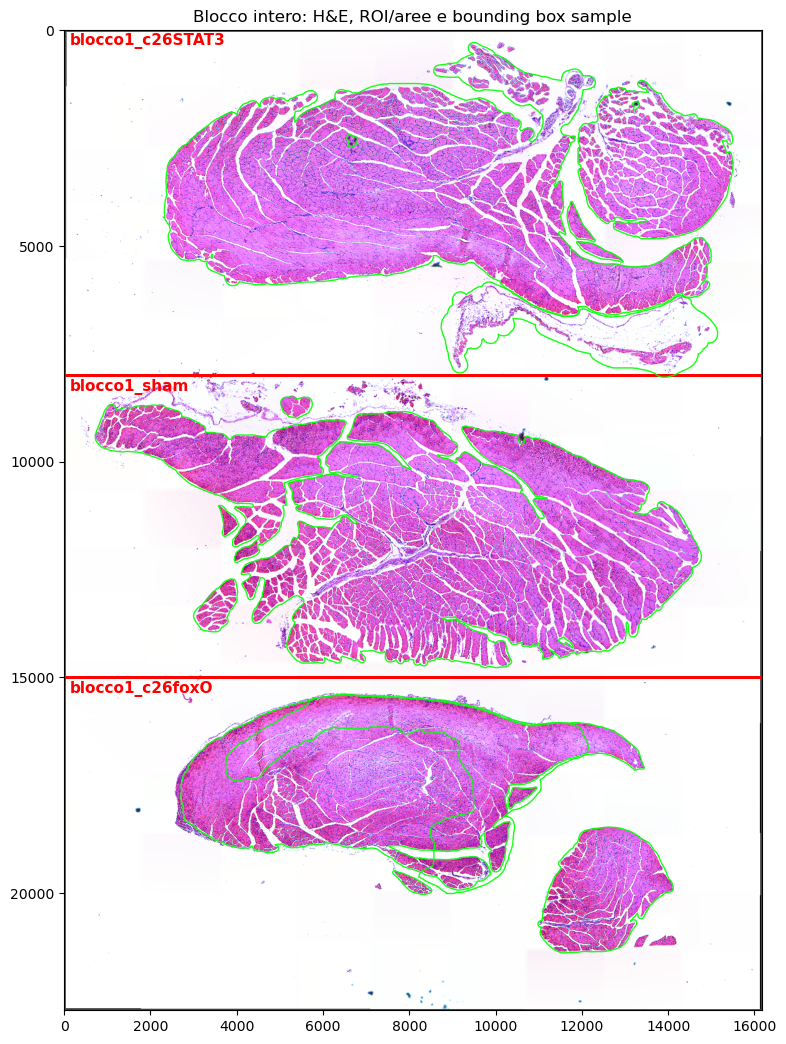

In [16]:
# Overview blocco intero: H&E full-res ridotta, bounding box dei 3 sample, ROI macro e aree/poligoni.
overview = read_rgb_overview(PATHS["he_fullres"], max_size=2400)
full_w, full_h = image_size(PATHS["he_fullres"])

fig, ax = plt.subplots(figsize=(9, 13))
ax.imshow(overview, extent=[0, full_w, full_h, 0])

if "roi_metadata" in globals() and len(roi_metadata) > 0:
    roi_metadata.boundary.plot(ax=ax, color="lime", linewidth=1.0, alpha=0.9)

# Se sono molti poligoni, il boundary e' disegnato molto sottile per non coprire l'H&E.
if "areas_of_interest" in globals() and len(areas_of_interest) > 0:
    areas_of_interest.geometry.boundary.plot(ax=ax, color="white", linewidth=0.15, alpha=0.25)

for sample_name, info in SAMPLES.items():
    x, y, w, h = sample_bbox(info)
    ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=2))
    ax.text(x + 120, y + 350, info.get("sample_key", sample_name), color="red", fontsize=11, weight="bold")

ax.set_title("Blocco intero: H&E, ROI/aree e bounding box sample")
ax.set_xlim(0, full_w)
ax.set_ylim(full_h, 0)
ax.set_aspect("equal")
plt.show()


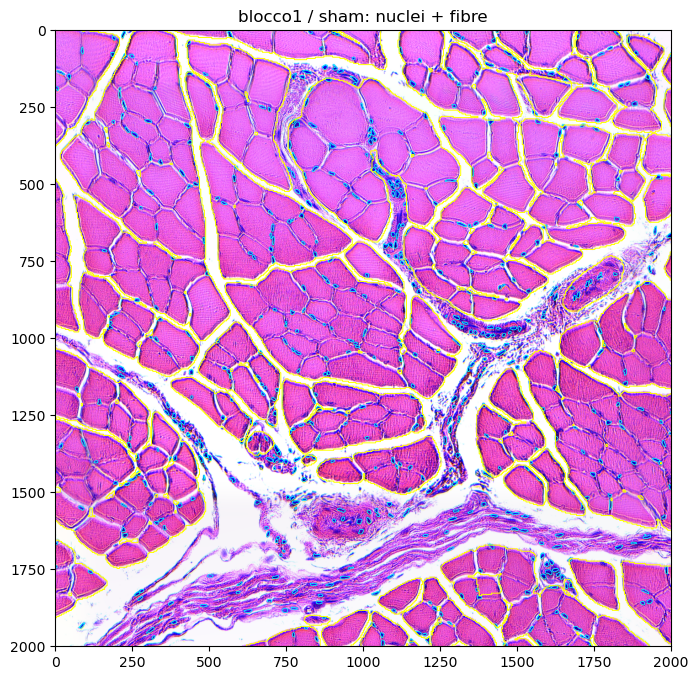

In [21]:
# Crop singolo del blocco: H&E + contorni nuclei ARVIS in ciano + fibre CellPose in giallo.
# Modifica sample_name o crop_size per ispezionare altre zone.
sample_name = "sham"
crop_size = 2000
x0, y0, w, h = centered_window(SAMPLES[sample_name], size=crop_size)
plot_segmentation_window(x0, y0, w, h, title=f"{BLOCK} / {sample_name}: nuclei + fibre", global_coordinates=False)
plt.show()


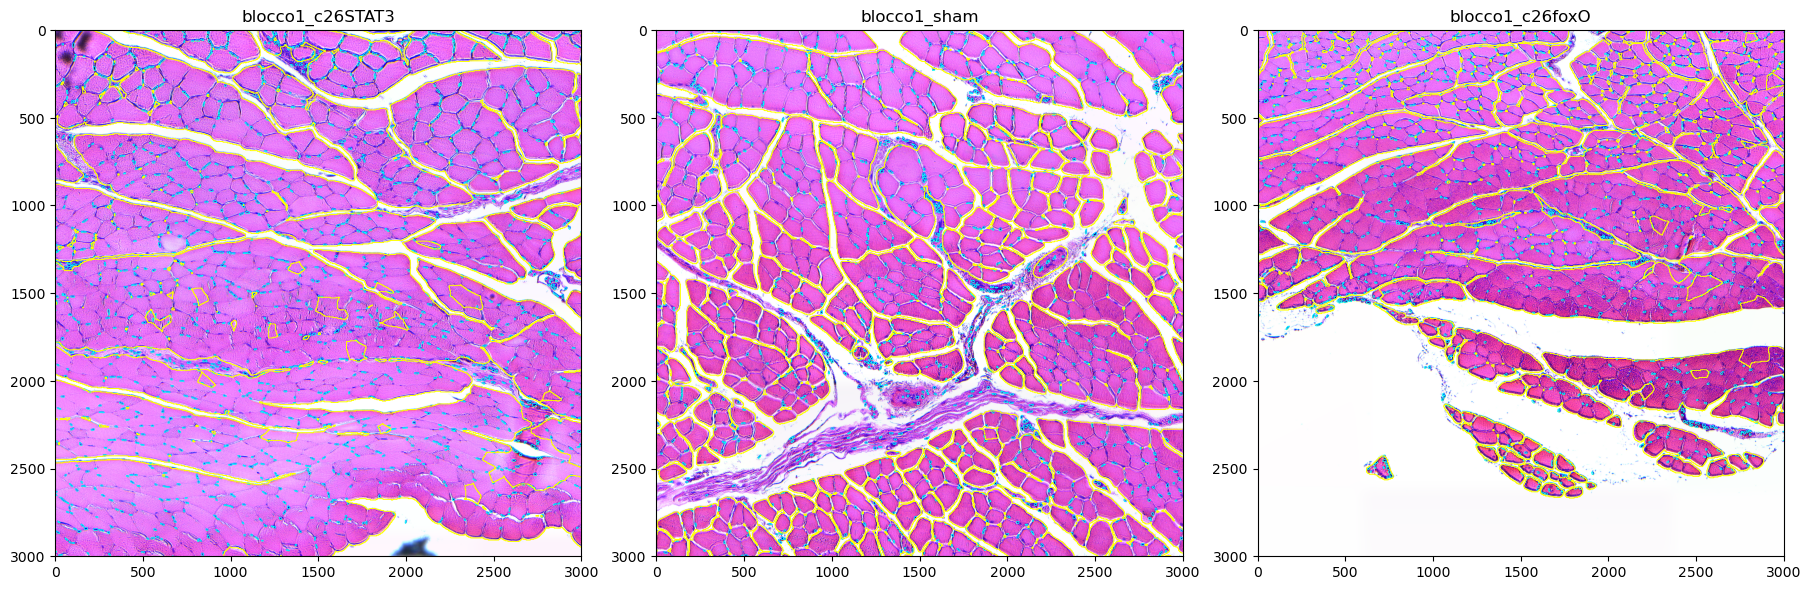

In [23]:
# Stesso controllo per tutti i sample ritagliati.
fig, axes = plt.subplots(1, len(SAMPLES), figsize=(6 * len(SAMPLES), 6), constrained_layout=True)
if len(SAMPLES) == 1:
    axes = [axes]

for ax, (sample_name, info) in zip(axes, SAMPLES.items()):
    x0, y0, w, h = centered_window(info, size=3000)
    plot_segmentation_window(
        x0,
        y0,
        w,
        h,
        title=f"{info.get('sample_key', sample_name)}",
        ax=ax,
        global_coordinates=False,
    )
plt.show()


In [19]:
# Controllo strutturale degli SpatialData salvati: chiavi e metadati dei ritagli.
print("Blocco intero")
print("  images:", list(sdata_block.images))
print("  labels:", list(sdata_block.labels))
print("  shapes:", list(sdata_block.shapes))
print("  tables:", list(sdata_block.tables))

print("\nSample ritagliati")
for sample_key, sdata_sample in sample_sdatas.items():
    print(f"\n{sample_key}")
    print("  images:", list(sdata_sample.images))
    print("  labels:", list(sdata_sample.labels))
    print("  shapes:", list(sdata_sample.shapes))
    print("  attrs:", {k: sdata_sample.attrs[k] for k in sorted(sdata_sample.attrs)})


Blocco intero
  images: ['blocco1_full_image', 'blocco1_hires_image', 'blocco1_lowres_image']
  labels: ['nuclei_arvis_labels', 'fibres_cellpose_labels']
  shapes: ['blocco1_square_002um', 'blocco1_square_008um', 'blocco1_square_016um', 'blocco1_cell_segmentations', 'areas_of_interest_arvis', 'roi_metadata_arvis', 'nuclei_arvis_shapes', 'fibres_cellpose_shapes']
  tables: ['square_002um', 'square_008um', 'square_016um', 'cell_segmentations']

Sample ritagliati

blocco1_c26STAT3
  images: ['blocco1_full_image', 'blocco1_hires_image', 'blocco1_lowres_image']
  labels: ['nuclei_arvis_labels', 'fibres_cellpose_labels']
  shapes: ['blocco1_square_002um', 'blocco1_square_008um', 'blocco1_square_016um', 'blocco1_cell_segmentations', 'areas_of_interest_arvis', 'roi_metadata_arvis', 'nuclei_arvis_shapes', 'fibres_cellpose_shapes']
  attrs: {'block_id': 'blocco1', 'crop_max_coordinate': [16166, 8000], 'crop_min_coordinate': [0, 0], 'sample_id': 'c26STAT3', 'sample_key': 'blocco1_c26STAT3'}

bloc

## Note operative

- `data/spatialdata/blocco1.zarr` contiene il blocco intero, utile come sorgente completa.
- `data/spatialdata/blocco1_c26STAT3.zarr`, `data/spatialdata/blocco1_sham.zarr`, `data/spatialdata/blocco1_c26foxO.zarr` sono i tre ritagli definiti da `data/samples_he.json`.
- `data/spatialdata/blocco1_samples_merged.zarr` contiene i tre sample riuniti con chiavi prefissate.
- Per analisi sulle aree di interesse usare `areas_of_interest_arvis`; se il GeoJSON contiene `label_id`, gli stessi poligoni sono disponibili anche come `nuclei_arvis_shapes`. Per visualizzazione/controllo delle maschere originali usare `nuclei_arvis_labels` e `fibres_cellpose_labels`.
- Se la conversione della maschera fibre in poligoni e' troppo lenta o produce uno zarr troppo grande, impostare `MAKE_POLYGONS_FROM_MASKS = False` e generare i poligoni solo sui sample ritagliati o solo quando servono.